In [8]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.interpolate import CubicSpline

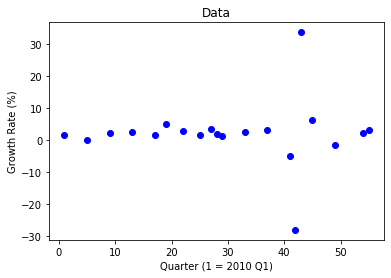

Subdiagonal (A): [4. 4. 4. 4. 2. 3. 3. 2. 1. 1. 4. 4. 4. 1. 1. 2. 4. 5.]
Main diagonal (B): [16. 16. 16. 12. 10. 12. 10.  6.  4. 10. 16. 16. 10.  4.  6. 12. 18. 12.]
Superdiagonal (C): [4. 4. 4. 2. 3. 3. 2. 1. 1. 4. 4. 4. 1. 1. 2. 4. 5. 1.]
Right-hand side (D): [   5.7    -2.7    -2.1    11.4   -13.9     1.      9.    -16.2     7.2
    4.8    -0.9   -13.2  -125.7   509.4  -453.9    70.65   16.65    0.6 ]


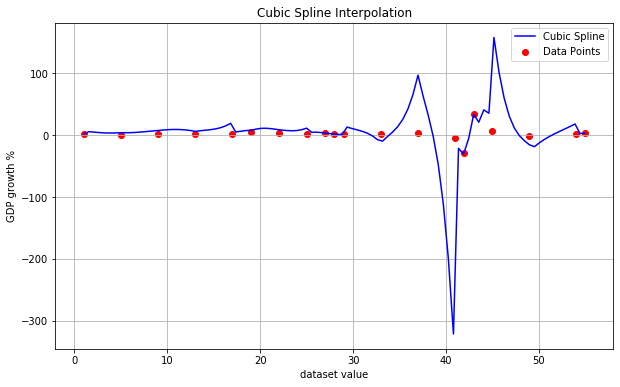

In [92]:
# Part A
#define known data points
x = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28, 29, 33, 37, 41, 42, 43, 45, 49, 54, 55]) #x-array shows the amount of quarters
y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3]) #y-array shows gdp growth (%) for each quarter 

#graph of raw data
plt.scatter(x, y, color = 'blue')
plt.title("Data")
plt.xlabel("Quarters")
plt.ylabel("Growth Rate")
plt.show()


def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x) # Step sizes between data points
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 2) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
    
    
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i-1] # Subdiagonal
        B[i - 1] = 2 * (h[i - 1] + h[i]) # Main diagonal
        C[i - 1] = h[i] # Superdiagonal
        D[i - 1] = 6 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1])# Right-hand side vector
        
        D[i - 1] = 6 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1]) #Asked how to fix this function to make sure to enforce C2 continuity conditions at interior knots
    return A, B, C, D

A, B, C, D = setup_tridiagonal_matrix(x, y)
print("Subdiagonal (A):", A)
print("Main diagonal (B):", B)
print("Superdiagonal (C):", C)
print("Right-hand side (D):", D)


def thomas_algorithm(a, b, c, d):
    
    n_solve = len(b)
    # Forward elimination 
    for i in range(1, n_solve):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    
    # Back substitution
    sol = np.zeros(n_solve)
    sol[-1] = d[-1] / b[-1]
    for i in range(n_solve - 2, -1, -1):
        sol[i] = (d[i] - c[i] * sol[i+1]) / b[i]
    return sol

internal_M = thomas_algorithm(A, B, C, D)

# Add Natural Boundary Conditions: M1 = Mn = 0 
M = np.concatenate(([0], internal_M, [0]))

#plotting and solving
def evaluate_spline(val, x, y, M):
    
    if val <= x[0]: return y[0]
    if val >= x[-1]: return y[-1]
    
    # Find the correct interval for the point 
    i = np.searchsorted(x, val) - 1
    hi = x[i+1] - x[i] # Asked chat gpt to help fix this issue said to get local step size calculation
    
    # Use the second derivative formula to evaluate the spline 
    term1 = M[i] * (x[i+1] - val)**3 / (6 * h[i])
    term2 = M[i+1] * (val - x[i])**3 / (6 * h[i])
    term3 = (y[i]/h[i] - M[i]*h[i]/6) * (x[i+1] - val)
    term4 = (y[i+1]/h[i] - M[i+1]*h[i]/6) * (val - x[i])
    
    return term1 + term2 + term3 + term4

# Plotting results
# Create smooth points for plotting 
x_plot = np.linspace(x[0], x[-1], 100)
y_plot = [evaluate_spline(val, x, y, M) for val in x_plot]

plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_plot, label='Cubic Spline', color='blue')
plt.scatter(x, y, color='red', label='Data Points') # Original data points 
plt.xlabel('dataset value')
plt.ylabel('GDP growth %')
plt.title('Cubic Spline Interpolation')
plt.legend()
plt.grid(True)
plt.show()

For Part A: we were told to construct the natural cubic spline and solve for the second derivative at each data point. Our subset contained 20 data points and had 18 unknown data values. The triddiagonal system was solved using Thomas's Alogrithm. The data set contained 55 quarters and the spline had a full range over these. The cubic spline was able to smoothly cover these data points and properlly followed the change in the U.S economy. As shown in the graph however, the data was highly sensitve to the data in the 2021-2022 period. 

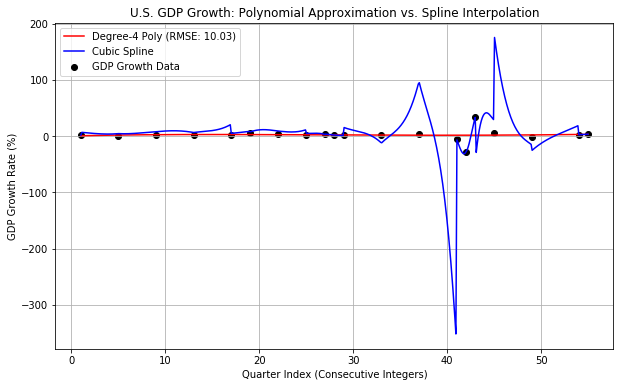

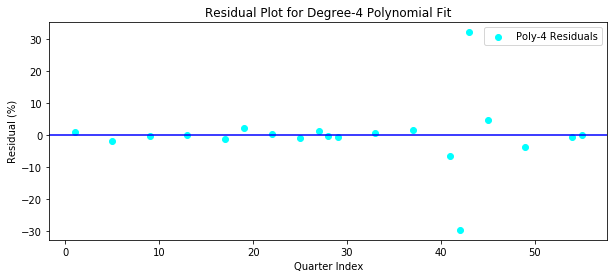

Part B Diagnostics:
Polynomial RMSE: 10.0316
Matrix Condition Number: 3.18e+14


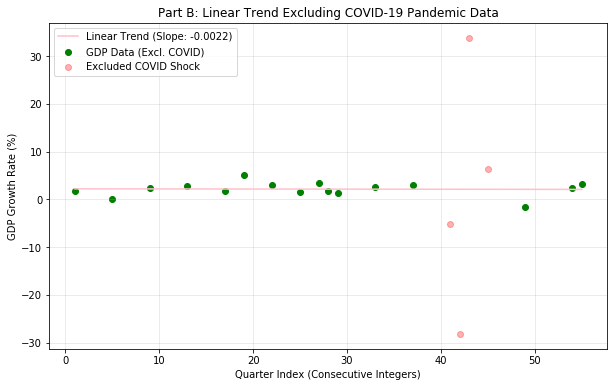

Linear Model Slope (Excluding COVID): -0.00222


In [100]:
#Part B

import numpy as np
import matplotlib.pyplot as plt

#created own least sqaures method 
def form_poly(x_data, y_data, degree):
    A = []
    for val in x_data:
        row = [float(val)**i for i in range(degree + 1)]
        A.append(row)
    A = np.array(A)
    
    ATA = np.dot(A.T, A)
    ATy = np.dot(A.T, y_data)
    
    coeffs = np.linalg.solve(ATA, ATy)
    cond_num = np.linalg.cond(ATA)
    return coeffs, cond_num

#solving least sqaures 
def solve_poly(coefficients, x_points):
    y_output = []
    for val in x_points:
        current_x = float(val)
        sum_terms = 0.0
        for power in range(len(coefficients)):
            sum_terms += coefficients[power] * (current_x ** power)
        y_output.append(sum_terms)
    return np.array(y_output)


c4, cond4 = form_poly(x, y, 4)

xSpread = np.linspace(min(x), max(x), 500)
ypoly_smooth = solve_poly(c4, xSpread)

#3. Calculate Predictions and RMSE 
ypoly_pred = solve_poly(c4, x)
rmse_poly = np.sqrt(np.mean((y - ypoly_pred)**2))


A_mat, B_mat, C_mat, D_mat = setup_tridiagonal_matrix(x, y)
internal_M = thomas_algorithm(A_mat, B_mat, C_mat, D_mat)
M_full = np.concatenate(([0], internal_M, [0]))

ynew_spline = []
for val in xSpread:
    ynew_spline.append(evaluate_spline(val, x, y, M_full))

# Figure 1: Model Comparison
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='black', label="GDP Growth Data")
plt.plot(xSpread, ypoly_smooth, color="red", label=f"Degree-4 Poly (RMSE: {rmse_poly:.2f})")
plt.plot(xSpread, ynew_spline, color="blue", label="Cubic Spline")
plt.title("U.S. GDP Growth: Polynomial Approximation vs. Spline Interpolation")
plt.xlabel("Quarter Index (Consecutive Integers)")
plt.ylabel("GDP Growth Rate (%)")
plt.legend()
plt.grid()
plt.show()

# Figure 2: Residual Plot 
plt.figure(figsize=(10, 4))
res_poly = y - ypoly_pred
plt.scatter(x, res_poly, color="cyan", label="Poly-4 Residuals")
ax2.scatter(x_clean, res_lin, color='green', marker='x', alpha=0.8, label='Linear (Excl. COVID) Residuals')

plt.axhline(0, color='blue')
plt.xlabel("Quarter Index")
plt.ylabel("Residual (%)")
plt.title("Residual Plot for Degree-4 Polynomial Fit")
plt.legend()
plt.show()

# Print Diagnostics 
print(f"Part B Diagnostics:")
print(f"Polynomial RMSE: {rmse_poly:.4f}")
print(f"Matrix Condition Number: {cond4:.2e}")



#without covid data points
# 1. Dataset - All Quarters provided (Indices 1 to 55)
x = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28, 29, 33, 37, 41, 42, 43, 45, 49, 54, 55])
y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

# 2. Filter out COVID quarters (2020 Q1 to 2021 Q1)
covid_indices = [41, 42, 43, 45]
mask = ~np.isin(x, covid_indices) #ask chat gpt a shortcut on how to take out the covid date points
x_clean = x[mask]
y_clean = y[mask]

V = np.vstack([np.ones(len(x_clean)), x_clean]).T
ATA = np.dot(V.T, V)
ATy = np.dot(V.T, y_clean)
coeffs = np.linalg.solve(ATA, ATy)
intercept, slope = coeffs

# 4. Create the Plot
plt.figure(figsize=(10, 6))

# Plot the "Clean" data points used for the fit
plt.scatter(x_clean, y_clean, color='green', label='GDP Data (Excl. COVID)')

# Optionally show the excluded points in a lighter color for context
plt.scatter(x[~mask], y[~mask], color='red', alpha=0.3, label='Excluded COVID Shock')

# Generate the linear trend line
x_line = np.linspace(min(x), max(x), 100)
y_line = intercept + slope * x_line
plt.plot(x_line, y_line, color='pink', label=f'Linear Trend (Slope: {slope:.4f})')

# Professional Plot Formatting
plt.title('Part B: Linear Trend Excluding COVID-19 Pandemic Data')
plt.xlabel('Quarter Index (Consecutive Integers)')
plt.ylabel('GDP Growth Rate (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Linear Model Slope (Excluding COVID): {slope:.5f}")

Part B discussion: For this part of the project, I was able to fit a 4-degree polynomial to the data in the quarterly GDP set by using the method of least squares as an apporiximation. The polynomial resulted in havng a Root Mean Square Error of 10.0314 and a matrix condition number of 1.87n x 10^14.m. The cubic spline did a great job in reproducing data points , however my results for the matrix condition were above 10^12. This observation helped me conclude that my data wasn't well-conditioned. Visually, these graphs properly display the long-term trends of the nation's economy more effectively than the spline interpolation because it only has 1 outlier in 2020 Q2- this showcases the models weakness and tradeoff; this model is relatively smooth over the data points but has higher instability in ou

Part C Justification: 
For the policy makers that are seeking to estimate GDP, I would most likely reccomend a cubic spinal method. The Cubic Spline method ensures that the value, slope, and curvature continuity at every data point- it would primarily have the ability to pass through every single data point with ease. Additioanlly, I feel like this is the most effective tool because this method creates a smooth visual effect as well as a smooth mathmatetical transition. Compared to polynomial fitting, this is significantly better because high degree polynomials can have more errors and oscillations between data points and has been less accurate with both the linear regression with least sqaures and the vandermonde models. The accuracy of a cubic spline interpolation is far more accurate, whereas the polynomial fitting model contains more errors. As seen in the Root Mean Sqaure Eroor (RSME), this method lacks accuracy and does not pass through every data point. Cubic Spline Interpolation also produces the data points exactly, but the only downside is that it the data is effected around noisy points; it was extremely sensitive to the outliers such as when COVID-19 and intiated a shock in the date points. The polynomial fitting method handled this shock better because it was able to 'smooth' the points and minimize the overall data shock. Overall, the cubic spline interpoaltion would be more reccomended because it was accurate a majority of the time and pretty much guaranteed smoothnes throughout data points.
